# Mpemba phase plots for several distances

### This section will be used to define my previous work as a function and loop over several distance meassures for comparison

In [1]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
#Define variables:
theta_list = np.linspace(0,np.pi,1000)
tlist = np.linspace(0, 12, 1000)

#Hilbert space dimension:
N = 2

#Constants:
w = 1
gamma = 1

#Creatrion/annihilation operator:
sigma = qt.destroy(N)
sigma_dag = sigma.dag()

#Operators:
Ham = w*sigma_dag*sigma

#Collapse operators:

c_ops = [np.sqrt(gamma) * sigma] 


#Ground state:
ground = qt.basis(2,0) * qt.basis(2,0).dag() #Evolved state

rho_list = []

for theta in theta_list: #Independent of phi!

    x = np.sin(theta)
    y = 0
    z = np.cos(theta)

    rho = 0.5 * (
        qt.qeye(2)
        + x * qt.sigmax()
        + y * qt.sigmay()
        + z * qt.sigmaz())

    rho_list.append(rho)


results = []
for rh0 in rho_list:
    results.append(qt.mesolve(Ham,rh0,tlist,c_ops))

    
all_rho_t = [res.states for res in results] #Gives a list of all rho(t), for different theta.

Assuming that $\rho$ is hermition: 

$D_F(\rho, \sigma) = \sqrt{\text{tr}\left[(\rho - \sigma)^2\right]}$

In [3]:
#Define the Frobenius distance

def frobenius(rho, evolved):#Function of roh and evolved state
    diff = (rho - evolved)**2
    tr_diff = diff.tr()
    
    return float(np.sqrt(tr_diff.real))

In [4]:
#Now calculate distances and calculate whether an Mpemba effect is present:
#Will use, Trace distance, frobenius, relative entropy, fidelity, bures distance, Hilbert-schmidt etc...

#Add frobenius in later, needs to be defined first...
distance_funcs = {"Trace": qt.tracedist,
                  "Frobenius": frobenius,
                  "Relative Entropy": qt.entropy_relative,
                  "Hilbert": qt.hilbert_dist,
                  "Bures": qt.bures_dist,
                  "Fidelity": qt.fidelity
                 }

#store results as a dictionary:
results = {}


#Loop over diferent distances: 
for name, dist_func in distance_funcs.items():
    Dist = []

    for rho_t in all_rho_t: #Loops over theta         
        D_t = [dist_func(rho, ground) for rho in rho_t] #Loops over time
        Dist.append(D_t)
        
    Dist = np.array(Dist)
    
    #Detect a cross over: 
    n_theta = Dist.shape[0] #Number of theta

    crossing_matrix = np.zeros((n_theta, n_theta), dtype=bool) #A true/false matrix of results to be plotted
    crossing_matrix.shape #Check its the expected shape.

    for i in range(n_theta):
        for j in range(i + 1, n_theta):#Skips repeated pairs of theta.
            diff = Dist[i] - Dist[j]

            #[:-1] ignores final data point and [1:] ignores the first. 
            #A cross between elements 2-3 will record as 2 here:
            
            #This method helps to stop zero errors, zeros will return false!
            has_crossing = np.any(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0) #Shifted data points are compared 

            crossing_matrix[i, j] = has_crossing
            crossing_matrix[j, i] = has_crossing  # symmetry

    Mpembas = crossing_matrix.astype(int) #changed True/false to 0/1 to be plotted
    
    # store result
    results[name] = {"Mpemba": Mpembas,
                     "Dist": Dist}

#results["Trace"]["Mpemba"] will give the data needed!

results["Trace"]["Mpemba"]

C:\Users\otrev\AppData\Local\Temp\ipykernel_19704\2771291692.py:35: RuntimeWarning: invalid value encountered in subtract
  diff = Dist[i] - Dist[j]


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 1, ..., 1, 0, 1],
       [0, 0, 1, ..., 1, 1, 0]])

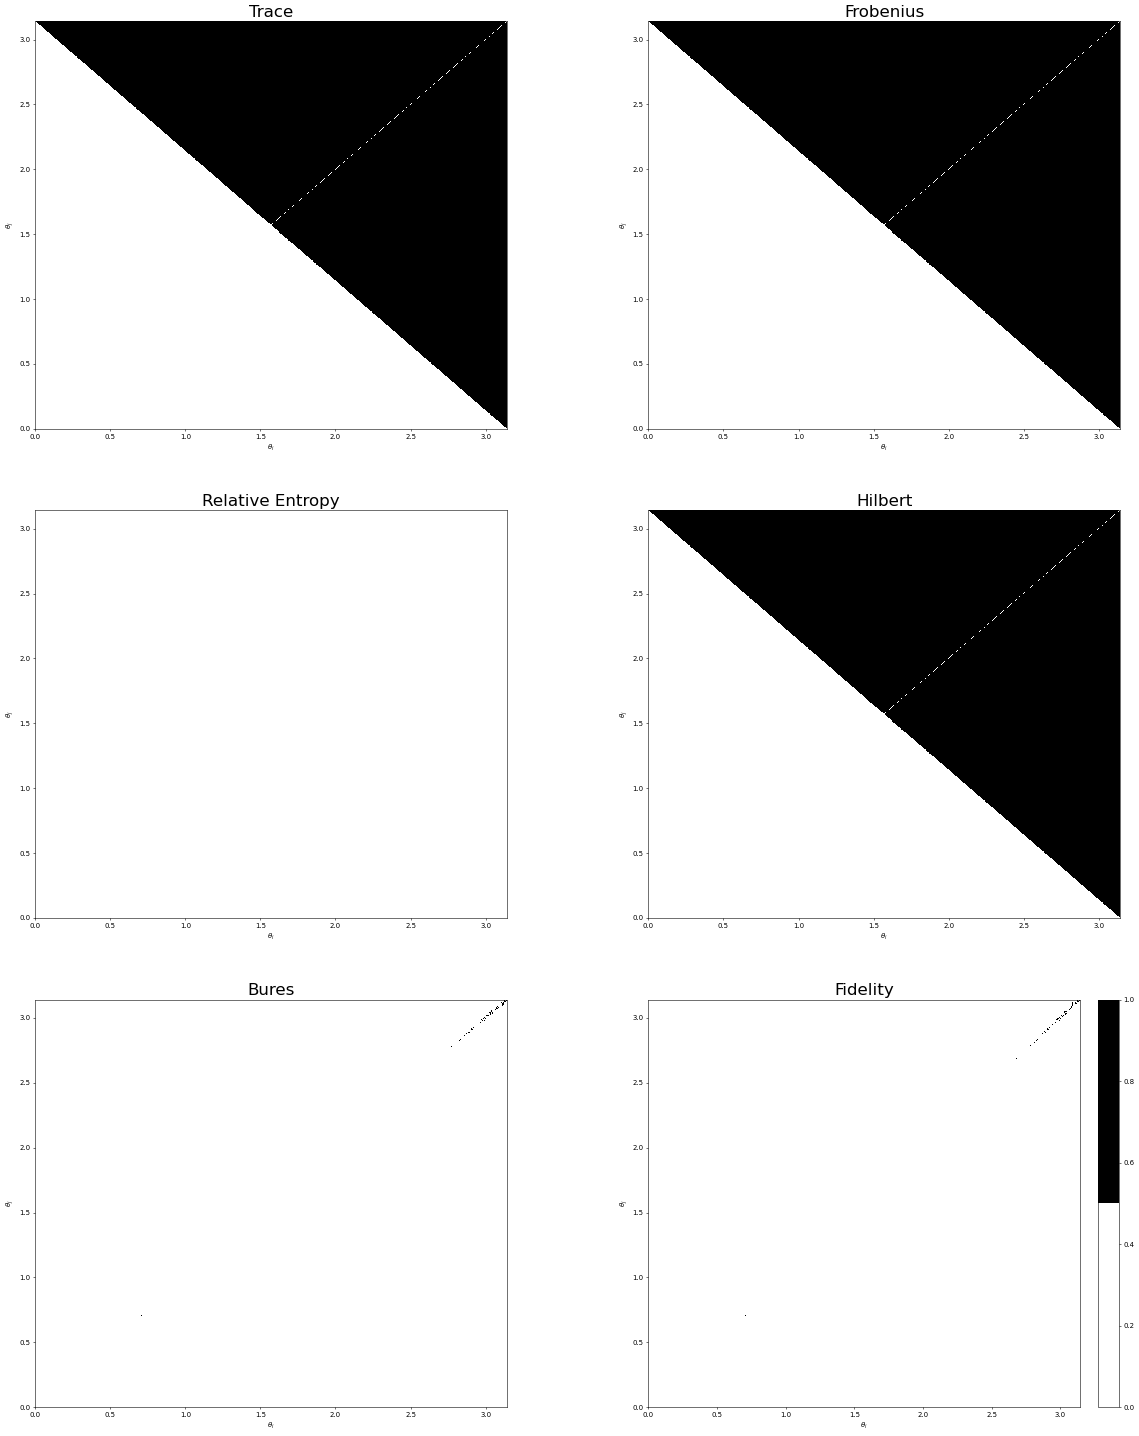

In [6]:
n_plots = len(results)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

import matplotlib
matplotlib.rcParams['figure.dpi'] = 50

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "black"])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14*n_cols, 12*n_rows))
axes = axes.flatten()

for ax, (name, data) in zip(axes, results.items()):
    
    im = ax.imshow(
        data["Mpemba"],
        origin="lower",
        cmap=cmap,
        interpolation='nearest',
        aspect='auto',
        extent=[0, np.pi, 0, np.pi]
    )

    ax.set_title(name, fontsize=24)
    ax.set_xlabel(r"$\theta_i$")
    ax.set_ylabel(r"$\theta_j$")
    


fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)

plt.subplots_adjust(wspace=0.3)